In [1]:
# Neural Network Analysis Demo
# This notebook demonstrates how to use the NetworkAnalyzer and WeightBinning classes

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Add parent directory to Python path to import from sibling directories
import sys
import os
# Get the absolute path of the current notebook's directory
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
# Get the parent directory
parent_dir = os.path.dirname(notebook_dir)
# Add parent directory to path
sys.path.append(parent_dir)

from Architectures.permutation_free_architecture import PermutationFreeNet
from Classes.weight_binning import WeightBinning
from Classes.network_analyzer import NetworkAnalyzer


def load_data(batch_size):
    csv_data = pd.read_csv('/home2/coles8/Large-Scale-Design-and-Analysis-of-Neural-Networks/data/simpleReg.csv')
    a = csv_data['a'].values.reshape(-1, 1)
    b = csv_data['b'].values.reshape(-1, 1)
    y = csv_data['y'].values.reshape(-1, 1)

    a_tensor = torch.tensor(a, dtype=torch.float32)
    b_tensor = torch.tensor(b, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    X_tensor = torch.cat((a_tensor, b_tensor), dim=1)

    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    return train_loader, test_loader

train_loader, test_loader = load_data(batch_size=64)

In [2]:
save_dir = "/home2/coles8/Large-Scale-Design-and-Analysis-of-Neural-Networks/outputs/packageTestPermFree"
all_networks_dir = "/home2/coles8/savedNetworks/"

# Set the architecture, save directory, and load path
architecture = PermutationFreeNet
wb_save_dir = f"{save_dir}/binning" 
# load_path = f"{save_dir}/working_networks.pt"
load_path = f"{all_networks_dir}/perm_free/perm_free_networks.pt"

# Instantiate WeightBinning
wb = WeightBinning(architecture=architecture, save_dir=wb_save_dir, load_path=load_path)


Number of networks loaded:
5270
Loaded models
Stored weights


In [3]:
# wb.analyze_distributions(
#     layer=0,
#     kl_threshold=0.001,
#     multi_peak=False,
#     peaks_per_layer=None,
#     random_state=42,
# )
layer_weight_distributions = wb.get_layer_weight_distributions()
print(len(layer_weight_distributions))

5


Normalizing distributions...
Fitting Gaussian models...
Clustering Gaussians with KL threshold 0.001...
Plotting unique Gaussian distributions for layer 0...
Plotting unique Gaussian cluster 0 at position (0, 0)


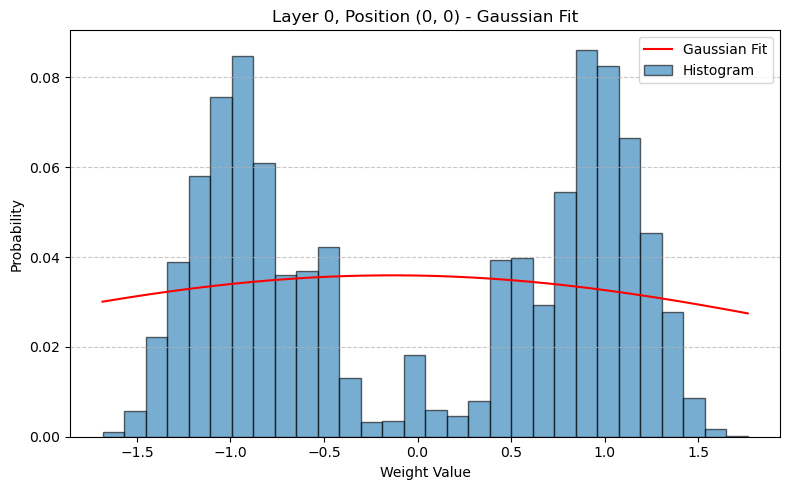

Plotting unique Gaussian cluster 1 at position (0, 1)


<Figure size 640x480 with 0 Axes>

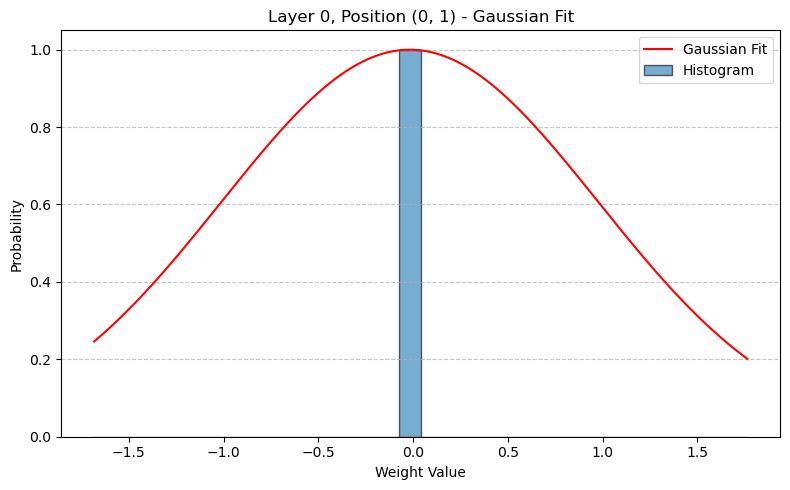

Plotting unique Gaussian cluster 2 at position (1, 1)


<Figure size 640x480 with 0 Axes>

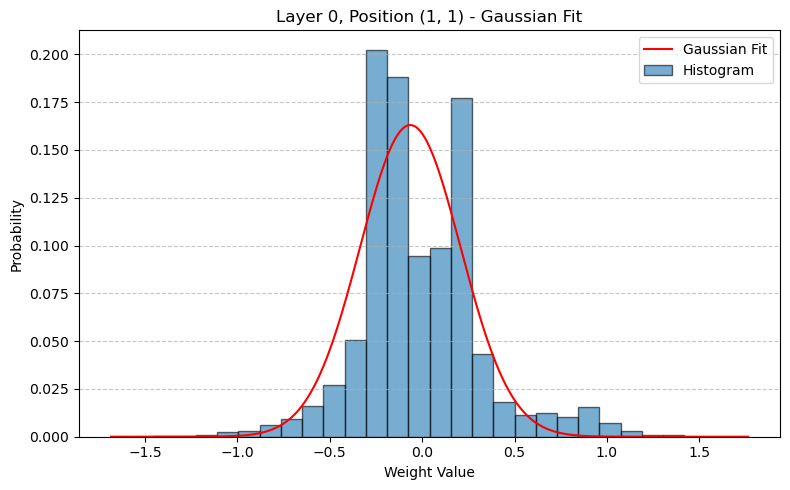

Plotting unique Gaussian cluster 3 at position (2, 1)


<Figure size 640x480 with 0 Axes>

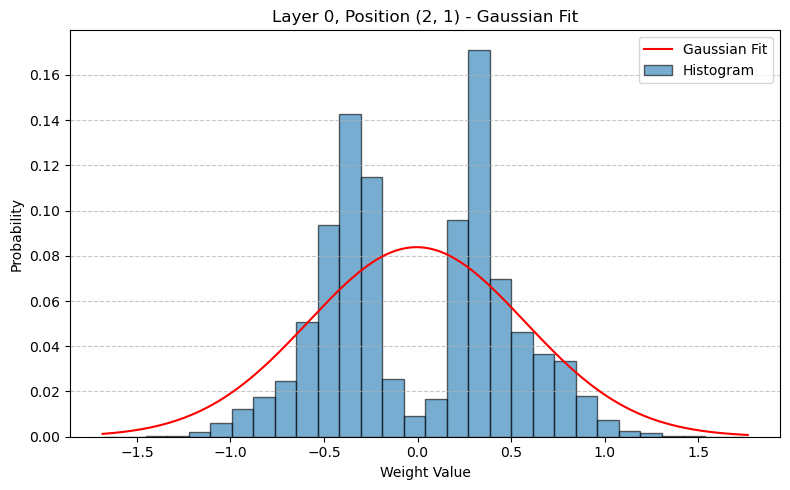

Found 4 unique Gaussian distributions in layer 0


[array([[0, 1],
        [1, 2],
        [1, 3]]),
 array([[0, 1, 0],
        [2, 1, 1],
        [3, 4, 1],
        [1, 0, 1],
        [1, 0, 5],
        [1, 1, 0]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  2,  5,  3,  3],
        [ 3,  3,  6,  7,  8,  3],
        [ 3,  3,  3,  7,  2,  7],
        [ 6,  3,  3,  3,  6,  7],
        [ 9, 10,  3,  3,  3,  7]]),
 array([[0, 0, 1, 2, 2, 2],
        [2, 0, 1, 0, 2, 2],
        [2, 2, 1, 3, 1, 2],
        [2, 2, 2, 0, 1, 0],
        [3, 2, 2, 2, 1, 4],
        [0, 0, 2, 2, 2, 4]]),
 array([[0, 0, 1, 0, 0, 2]])]

<Figure size 640x480 with 0 Axes>

In [4]:
wb.analyze_distributions(
    layer=0,
    kl_threshold=0.001,
    multi_peak=False,
    peaks_per_layer=None,
    random_state=42,
)

Fitting GMM models...
Clustering GMMs with KL threshold 0.001...
Plotting unique GMM distributions for layer 2...
Plotting unique GMM cluster 0 at position (0, 0)


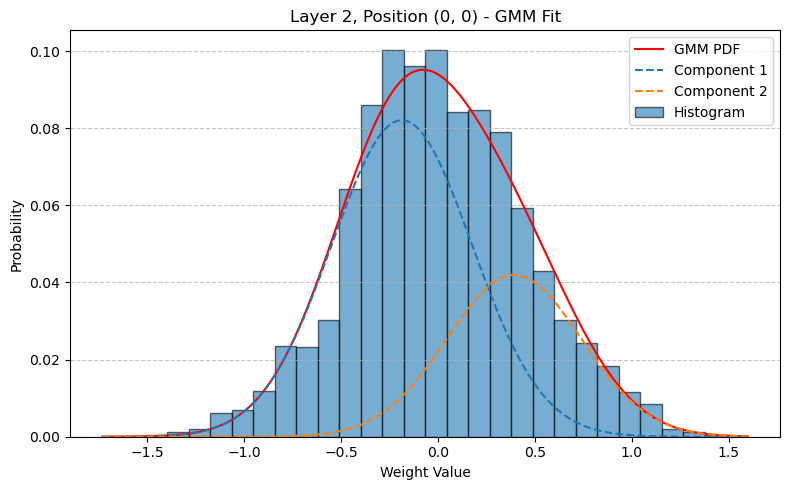

Plotting unique GMM cluster 1 at position (0, 1)


<Figure size 640x480 with 0 Axes>

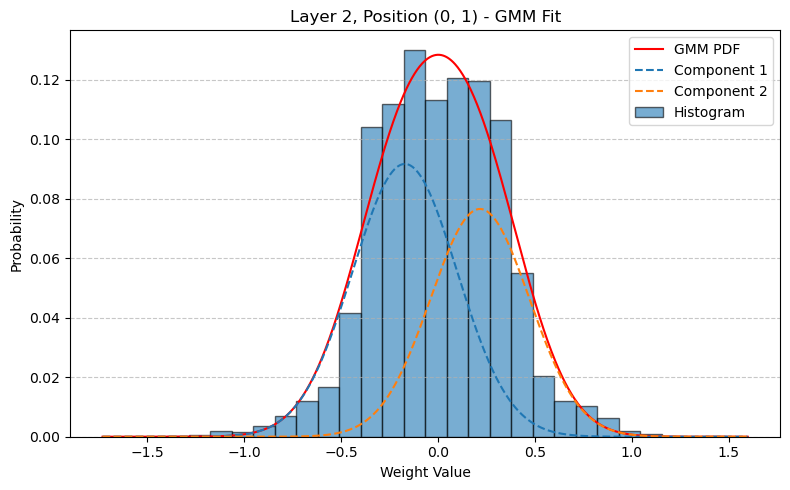

Plotting unique GMM cluster 2 at position (0, 2)


<Figure size 640x480 with 0 Axes>

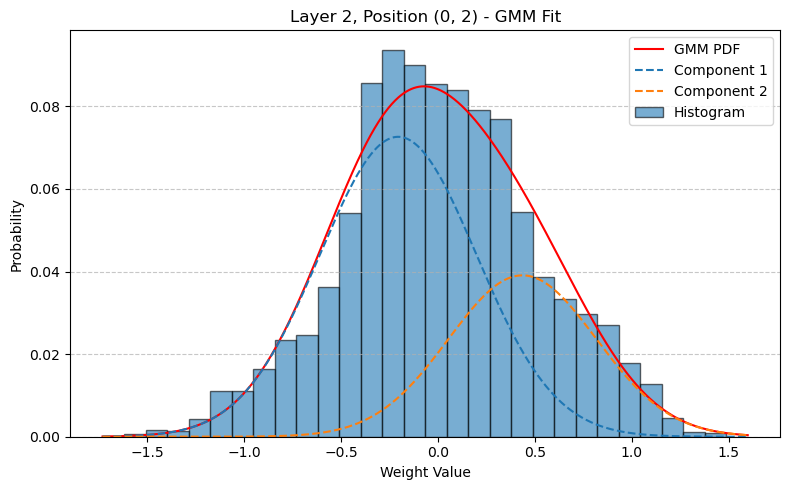

Plotting unique GMM cluster 3 at position (0, 3)


<Figure size 640x480 with 0 Axes>

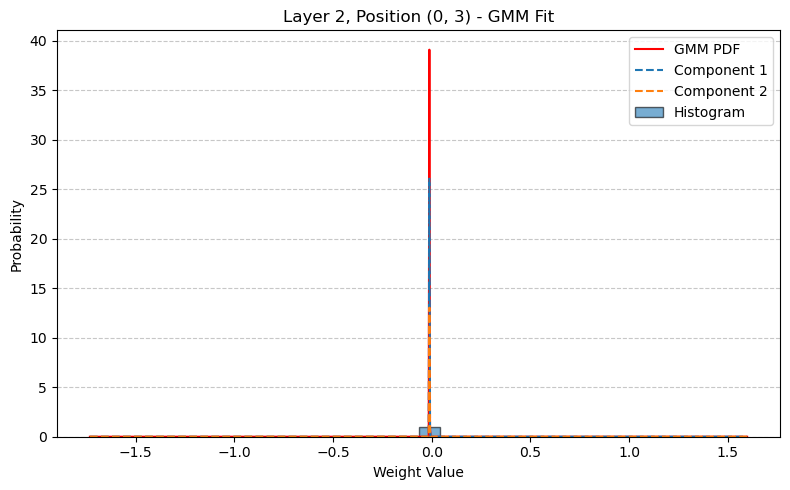

Plotting unique GMM cluster 4 at position (1, 1)


<Figure size 640x480 with 0 Axes>

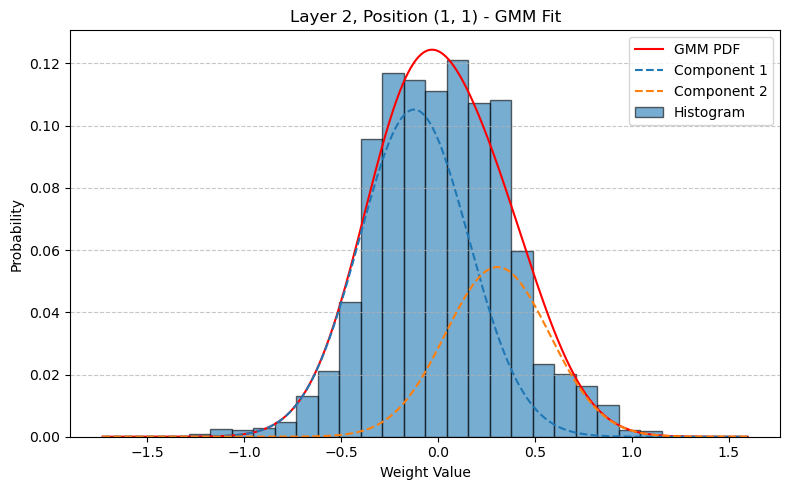

Plotting unique GMM cluster 5 at position (1, 2)


<Figure size 640x480 with 0 Axes>

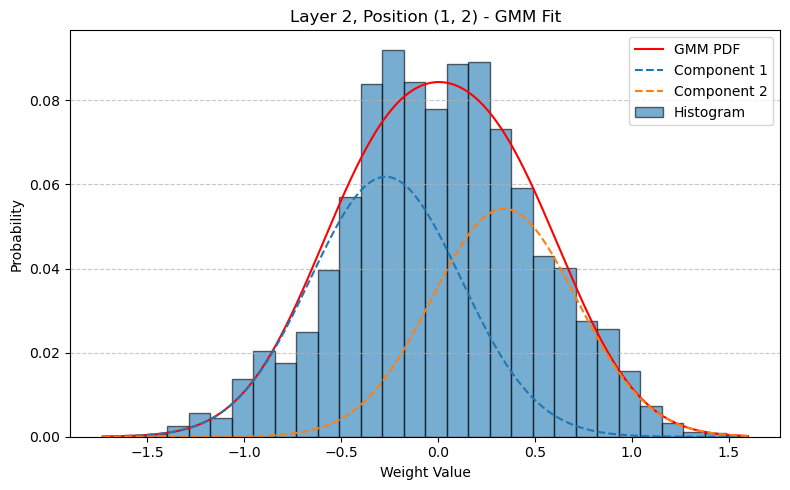

Plotting unique GMM cluster 6 at position (1, 3)


<Figure size 640x480 with 0 Axes>

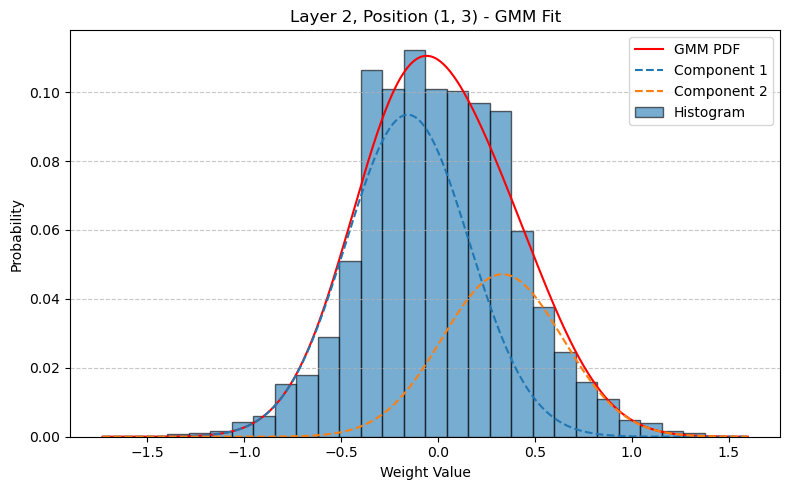

Plotting unique GMM cluster 7 at position (2, 2)


<Figure size 640x480 with 0 Axes>

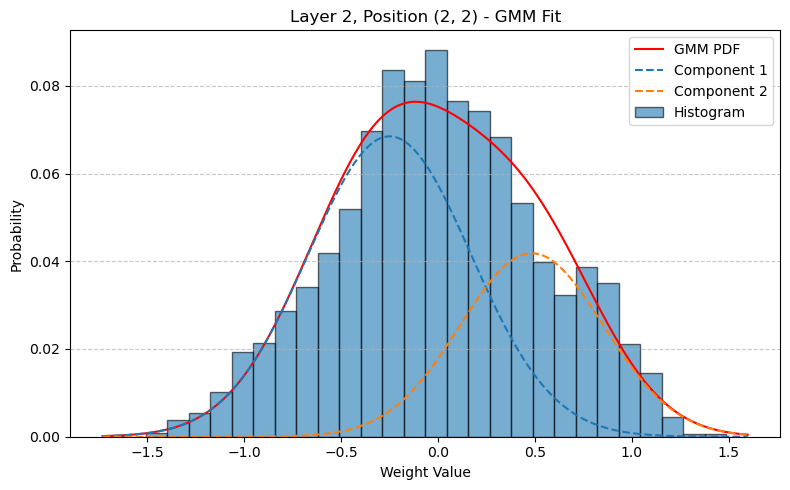

Plotting unique GMM cluster 8 at position (2, 3)


<Figure size 640x480 with 0 Axes>

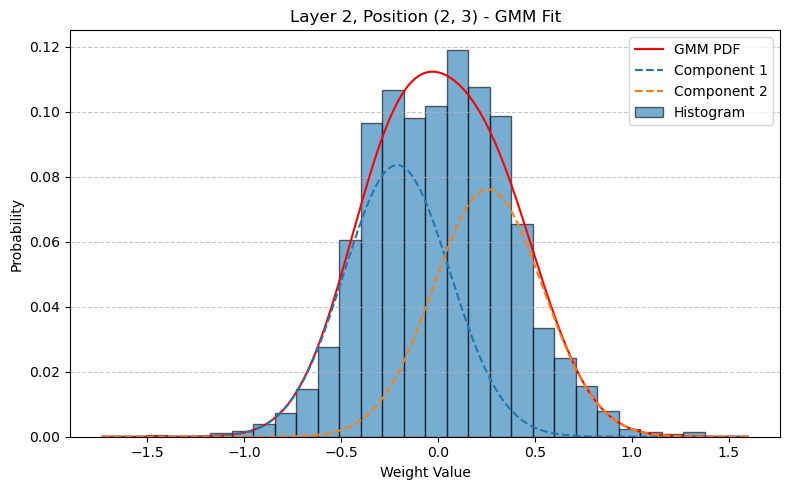

Plotting unique GMM cluster 9 at position (2, 4)


<Figure size 640x480 with 0 Axes>

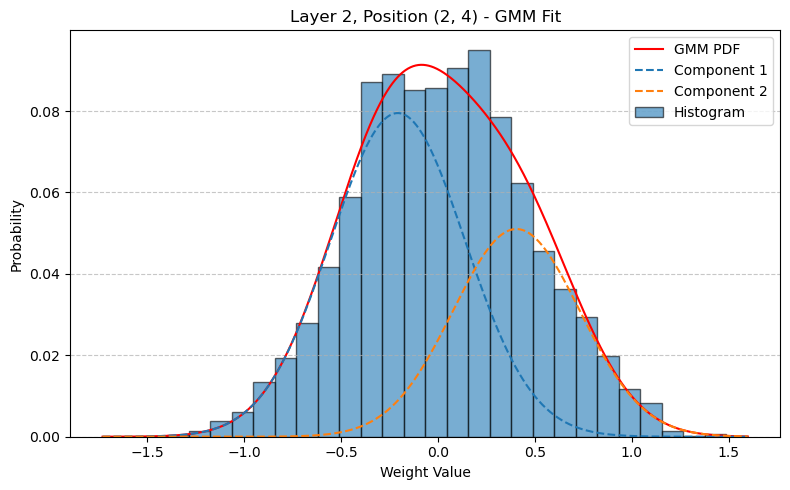

Plotting unique GMM cluster 10 at position (3, 3)


<Figure size 640x480 with 0 Axes>

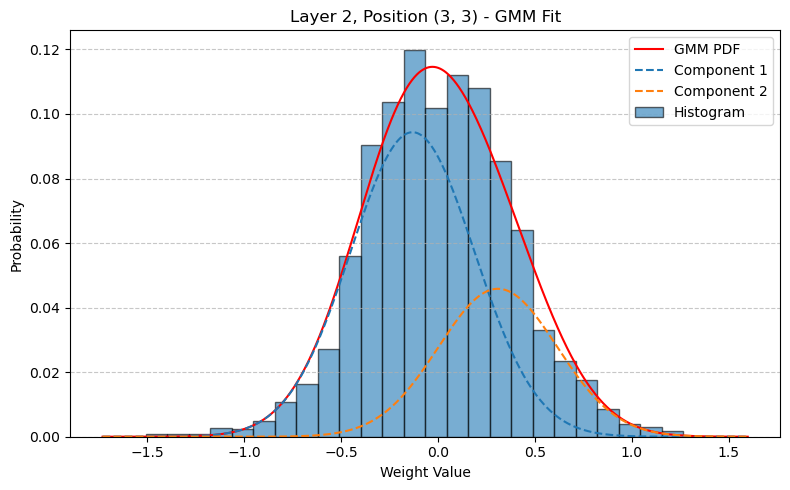

Plotting unique GMM cluster 11 at position (3, 4)


<Figure size 640x480 with 0 Axes>

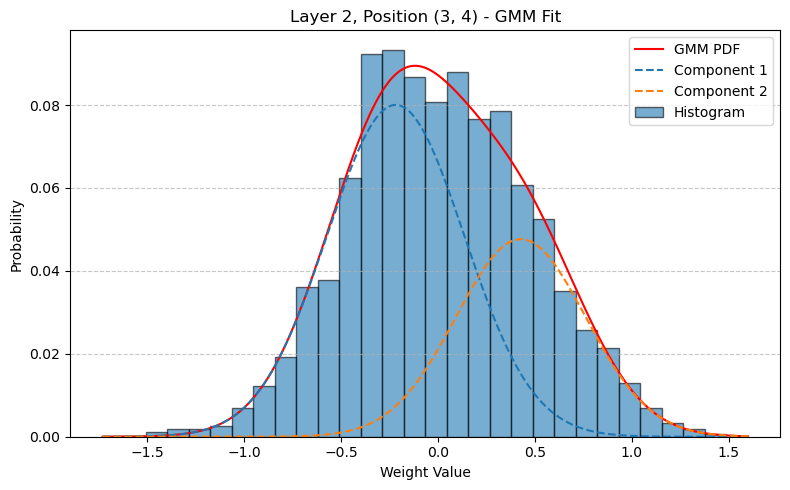

Plotting unique GMM cluster 12 at position (4, 0)


<Figure size 640x480 with 0 Axes>

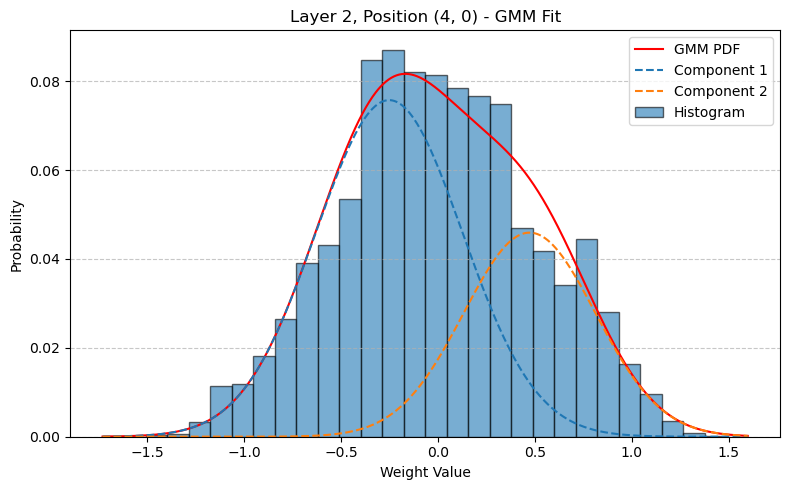

Plotting unique GMM cluster 13 at position (4, 5)


<Figure size 640x480 with 0 Axes>

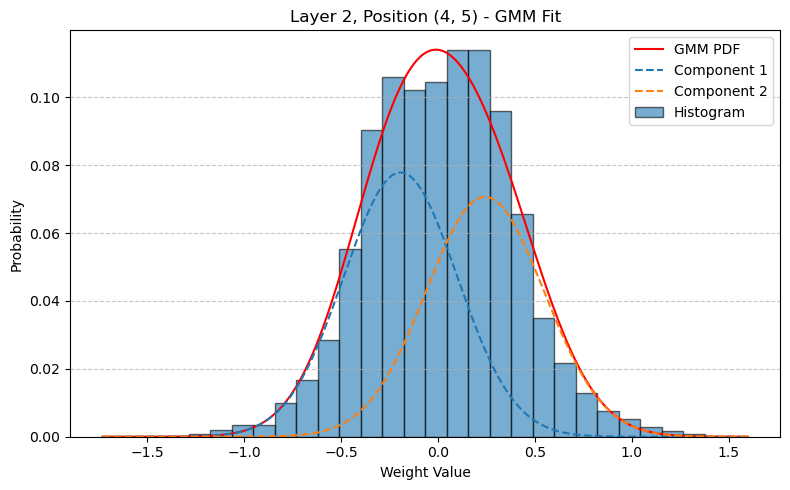

Plotting unique GMM cluster 14 at position (5, 0)


<Figure size 640x480 with 0 Axes>

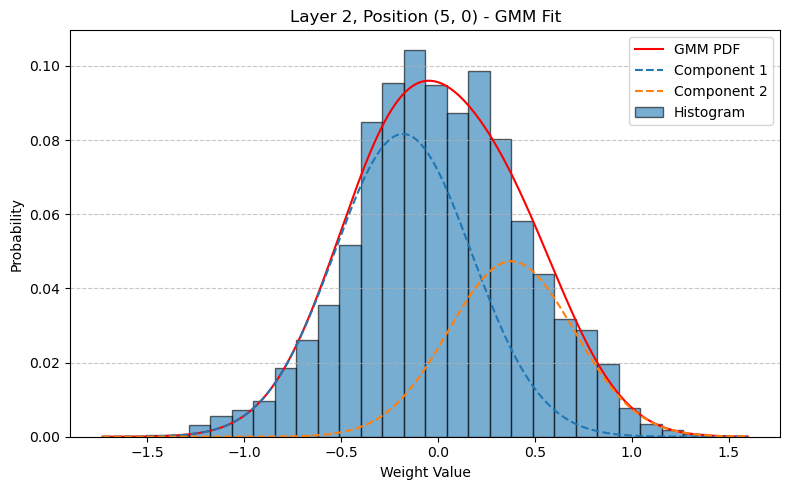

Plotting unique GMM cluster 15 at position (5, 1)


<Figure size 640x480 with 0 Axes>

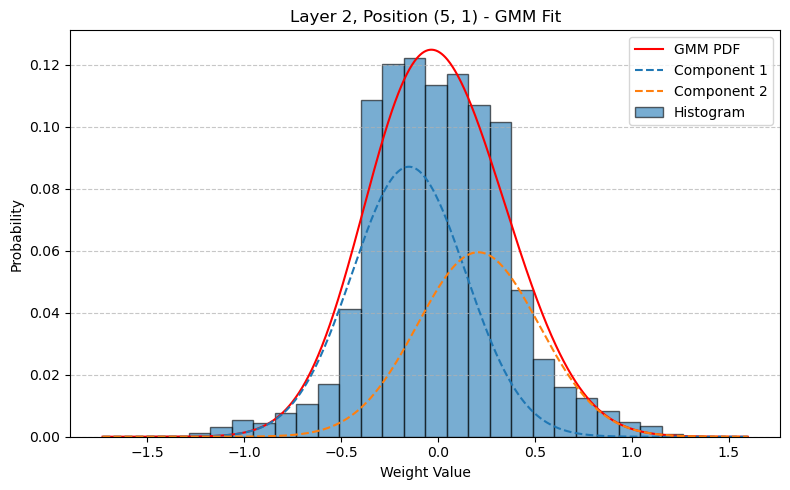

Found 16 unique GMM distributions in layer 2


[array([[0, 1],
        [2, 3],
        [1, 4]]),
 array([[0, 1, 2],
        [3, 1, 1],
        [4, 5, 1],
        [1, 6, 1],
        [1, 7, 8],
        [1, 1, 9]]),
 array([[ 0,  1,  2,  3,  3,  3],
        [ 3,  4,  5,  6,  3,  3],
        [ 3,  3,  7,  8,  9,  3],
        [ 3,  3,  3, 10, 11, 10],
        [12,  3,  3,  3, 12, 13],
        [14, 15,  3,  3,  3, 10]]),
 array([[0, 0, 1, 2, 2, 2],
        [2, 0, 3, 4, 2, 2],
        [2, 2, 3, 5, 6, 2],
        [2, 2, 2, 0, 3, 0],
        [0, 2, 2, 2, 3, 7],
        [0, 0, 2, 2, 2, 7]]),
 array([[0, 1, 2, 3, 0, 4]])]

<Figure size 640x480 with 0 Axes>

In [8]:
wb.analyze_distributions(
    layer=2,
    kl_threshold=0.001,
    multi_peak=True,
    peaks_per_layer=[2, 2, 2, 2, 2]
)